In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/bhakt/Downloads/owid-covid-data.csv")

# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

In [23]:
print(df.head())

  iso_code continent     location       date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan 2020-01-03          NaN        0.0   
1      AFG      Asia  Afghanistan 2020-01-04          NaN        0.0   
2      AFG      Asia  Afghanistan 2020-01-05          NaN        0.0   
3      AFG      Asia  Afghanistan 2020-01-06          NaN        0.0   
4      AFG      Asia  Afghanistan 2020-01-07          NaN        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         0.0                  NaN  ...   
1                 NaN           NaN         0.0                  NaN  ...   
2                 NaN           NaN         0.0                  NaN  ...   
3                 NaN           NaN         0.0                  NaN  ...   
4                 NaN           NaN         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN                  

In [24]:
print(df.tail())

       iso_code continent  location       date  total_cases  new_cases  \
350080      ZWE    Africa  Zimbabwe 2023-10-14     265808.0        0.0   
350081      ZWE    Africa  Zimbabwe 2023-10-15     265808.0        0.0   
350082      ZWE    Africa  Zimbabwe 2023-10-16     265808.0        0.0   
350083      ZWE    Africa  Zimbabwe 2023-10-17     265808.0        0.0   
350084      ZWE    Africa  Zimbabwe 2023-10-18     265808.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
350080               5.286        5718.0         0.0                  0.0   
350081               5.286        5718.0         0.0                  0.0   
350082               5.286        5718.0         0.0                  0.0   
350083               0.000        5718.0         0.0                  0.0   
350084               0.000        5718.0         0.0                  0.0   

        ...  male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
350080  ...

In [13]:
print(df.shape)

(350085, 67)


The dataset contains 350085 rows and 67 columns.

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

In [15]:
print(df.describe())

        total_cases     new_cases  new_cases_smoothed  total_deaths  \
count  3.120880e+05  3.404570e+05        3.391980e+05  2.905010e+05   
mean   6.683354e+06  9.601634e+03        9.637066e+03  8.602180e+04   
std    4.068903e+07  1.102769e+05        9.447784e+04  4.398873e+05   
min    1.000000e+00  0.000000e+00        0.000000e+00  1.000000e+00   
25%    8.090000e+03  0.000000e+00        2.860000e-01  1.270000e+02   
50%    7.020500e+04  2.000000e+00        2.485700e+01  1.328000e+03   
75%    7.409558e+05  2.640000e+02        4.978570e+02  1.192200e+04   
max    7.714071e+08  8.401961e+06        6.402036e+06  6.972139e+06   

          new_deaths  new_deaths_smoothed  total_cases_per_million  \
count  340511.000000        339281.000000            312088.000000   
mean       85.511055            85.817071            101749.851259   
std       613.687971           559.130004            151265.689121   
min         0.000000             0.000000                 0.000000   
25%       

In [16]:
print(df.isnull())

        iso_code  continent  location   date  total_cases  new_cases  \
0          False      False     False  False         True      False   
1          False      False     False  False         True      False   
2          False      False     False  False         True      False   
3          False      False     False  False         True      False   
4          False      False     False  False         True      False   
...          ...        ...       ...    ...          ...        ...   
350080     False      False     False  False        False      False   
350081     False      False     False  False        False      False   
350082     False      False     False  False        False      False   
350083     False      False     False  False        False      False   
350084     False      False     False  False        False      False   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
0                     True          True       False      

In [17]:
print(df.isnull().sum())

iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64


This shows the number of missing values in each column before cleaning.

In [18]:
empty_columns = df.columns[df.isnull().all()]
print("Completely empty columns :", empty_columns)

Completely empty columns : Index([], dtype='object')


# Data Cleaning :
The dataset contains missing values and aggregated rows. Cleaning is performed to ensure accurate analysis.

In [25]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending = False))

weekly_icu_admissions                         97.084994
weekly_icu_admissions_per_million             97.084994
excess_mortality_cumulative_per_million       96.519702
excess_mortality                              96.519702
excess_mortality_cumulative                   96.519702
excess_mortality_cumulative_absolute          96.519702
weekly_hosp_admissions                        93.357899
weekly_hosp_admissions_per_million            93.357899
icu_patients_per_million                      89.255467
icu_patients                                  89.255467
hosp_patients_per_million                     88.887842
hosp_patients                                 88.887842
total_boosters                                86.414157
total_boosters_per_hundred                    86.414157
new_vaccinations                              81.334247
people_fully_vaccinated                       79.269320
people_fully_vaccinated_per_hundred           79.269320
new_tests                                     78

In [26]:
# Show all rows
pd.set_option('display.max_rows', None)

# Calculate missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentage.sort_values(ascending=False).to_frame(name='Missing_Percentage')

# Display the result
missing_df

,Missing_Percentage
weekly_icu_admissions,97.084994
weekly_icu_admissions_per_million,97.084994
excess_mortality_cumulative_per_million,96.519702
excess_mortality,96.519702
excess_mortality_cumulative,96.519702
excess_mortality_cumulative_absolute,96.519702
weekly_hosp_admissions,93.357899
weekly_hosp_admissions_per_million,93.357899
icu_patients_per_million,89.255467
icu_patients,89.255467


# Dropping Unnecessary Columns (Continents) :
Removing rows where continent is missing to focus only on country-level data.

In [8]:
df = df[df['continent'].notna()]  
#filters the dataset to keep only the rows where the continent value is not missing.

In [9]:
columns_to_keep = [
    'iso_code', 'continent', 'location', 'date', 'population',
    'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
    'total_cases_per_million', 'total_deaths_per_million',
    'people_vaccinated', 'people_fully_vaccinated', 'total_vaccinations',
    'gdp_per_capita', 'median_age', 'hospital_beds_per_thousand',
    'human_development_index', 'life_expectancy',
    'stringency_index', 'reproduction_rate'
]

df = df[columns_to_keep]

In [4]:
print(df.head())

  iso_code continent     location       date  population  total_cases  \
0      AFG      Asia  Afghanistan 2020-01-03  41128772.0          NaN   
1      AFG      Asia  Afghanistan 2020-01-04  41128772.0          NaN   
2      AFG      Asia  Afghanistan 2020-01-05  41128772.0          NaN   
3      AFG      Asia  Afghanistan 2020-01-06  41128772.0          NaN   
4      AFG      Asia  Afghanistan 2020-01-07  41128772.0          NaN   

   new_cases  total_deaths  new_deaths  total_cases_per_million  ...  \
0        0.0           NaN         0.0                      NaN  ...   
1        0.0           NaN         0.0                      NaN  ...   
2        0.0           NaN         0.0                      NaN  ...   
3        0.0           NaN         0.0                      NaN  ...   
4        0.0           NaN         0.0                      NaN  ...   

   people_vaccinated  people_fully_vaccinated  total_vaccinations  \
0                NaN                      NaN              

## Data Cleaning

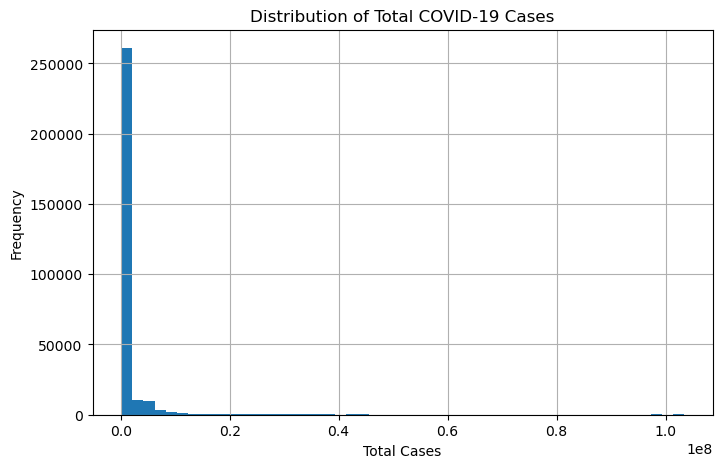

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['total_cases'].dropna(), bins=50)
plt.title('Distribution of Total COVID-19 Cases')
plt.xlabel('Total Cases')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

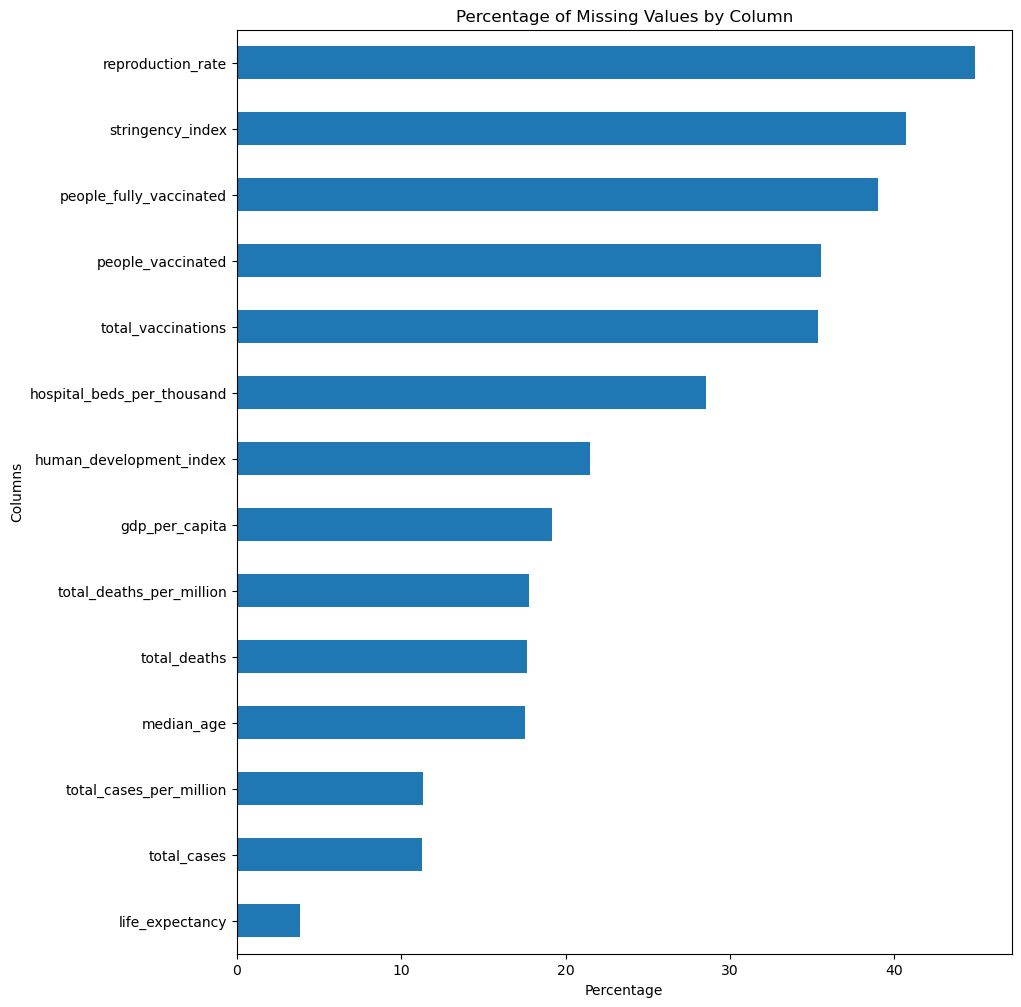

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values().plot(kind='barh', figsize=(10, 12))
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Percentage')
plt.ylabel('Columns')
plt.show()


In [12]:
# sort data
df = df.sort_values(by=['location', 'date'])

The dataset is sorted by location and date to maintain chronological order for each country.

Time-series consistency was maintained to ensure accurate trend analysis.

## Using forward fill :
Forward filling is used for cumulative columns such as total cases and deaths to maintain continuity in time-series data.


#### Why ?
Forward fill replaces missing values with the last known value, which is appropriate for cumulative data like total cases and total deaths.

In [13]:
cumulative_cols = [
    'total_cases', 'total_deaths',
    'people_vaccinated', 'people_fully_vaccinated',
    'total_vaccinations'
]

df[cumulative_cols] = df.groupby('location')[cumulative_cols].ffill()

In [14]:
# fill mmissing values of new_cases and new_deaths as 0 

df[['new_cases', 'new_deaths']] = df[['new_cases', 'new_deaths']].fillna(0)

In [15]:
# These values are constant for each country, not changing daily.
socio_cols = [
    'gdp_per_capita', 'median_age',
    'hospital_beds_per_thousand',
    'human_development_index', 'life_expectancy'
]

for col in socio_cols:
    df[col] = df.groupby('location')[col].transform(lambda x: x.fillna(x.median()))

In [17]:
# Handle Remaining Missing Values
df = df.fillna(0)

Daily columns such as new cases and new deaths were filled with zero, while socio-economic data was filled using appropriate statistical methods.

In [18]:
print(df.isnull().sum())

iso_code                      0
continent                     0
location                      0
date                          0
population                    0
total_cases                   0
new_cases                     0
total_deaths                  0
new_deaths                    0
total_cases_per_million       0
total_deaths_per_million      0
people_vaccinated             0
people_fully_vaccinated       0
total_vaccinations            0
gdp_per_capita                0
median_age                    0
hospital_beds_per_thousand    0
human_development_index       0
life_expectancy               0
stringency_index              0
reproduction_rate             0
dtype: int64


In [20]:
df.to_csv("cleaned_covid_data.csv", index=False)

## Summary of Data Cleaning

- Removed aggregated regions to focus on country-level data  
- Handled missing values using forward fill and appropriate techniques  
- Converted date column to datetime format  
- Sorted dataset to maintain time-series consistency  

The cleaned dataset is now ready for accurate and meaningful analysis.